✅ Archivo encontrado: C:\Users\Davd Lopez\OneDrive - Universidad de la Sabana\unisabana\Octavo semestre\IA\Proyecto\tournament\groups\David Eduardo Lopez Jimenez\policy.py
✅ Archivo encontrado: C:\Users\Davd Lopez\OneDrive - Universidad de la Sabana\unisabana\Octavo semestre\IA\Proyecto\tournament\groups\Martin jerez\policy.py
✅ Archivo encontrado: C:\Users\Davd Lopez\OneDrive - Universidad de la Sabana\unisabana\Octavo semestre\IA\Proyecto\tournament\groups\Oscar Vergara\policy.py

Cargando agentes...
   → Clase 'Aha' detectada en policy.py
   → Clase 'QLearningAgent' detectada en policy.py
   → Clase 'MCTSAgentOscarQ' cargada tras corregir indentación
✅ Todos los agentes cargados correctamente.


Creando instancias...
   🔧 Martín Jerez: clase abstracta, creando subclase con métodos implementados
   ✅ Martín Jerez: instanciado como subclase concreta
   ✅ David (Heurístico): montado
   ✅ Martín Jerez: montado
   ✅ Oscar Vergara: montado
   ✅ Random (Base): montado

✅ Agentes que partic

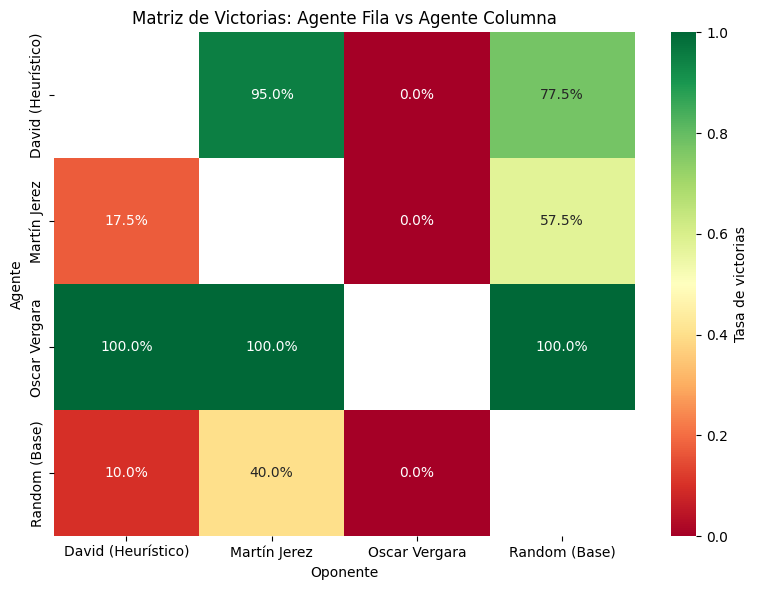

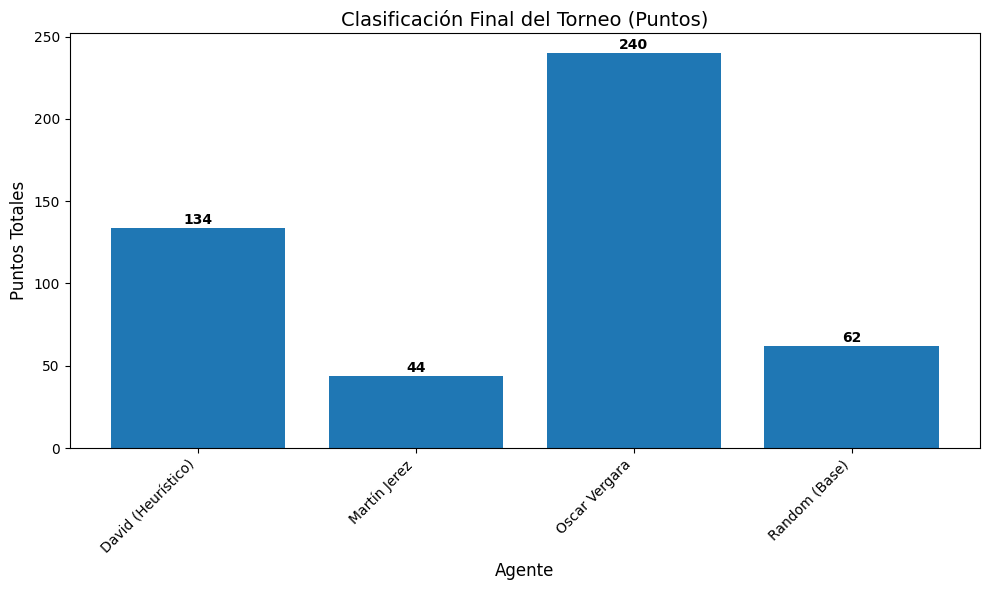

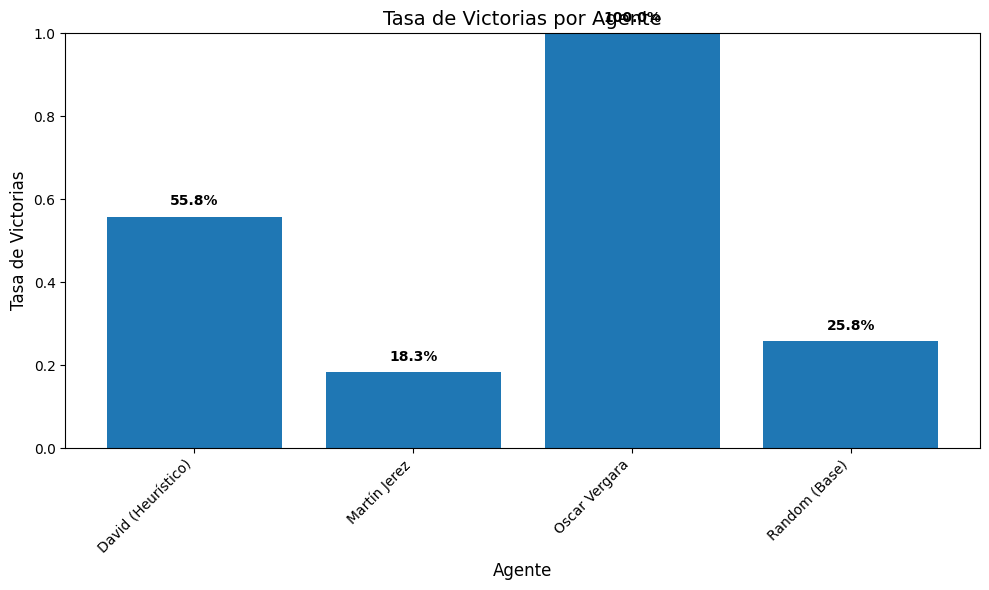

In [22]:
import sys
import os
import importlib.util
import types
import re
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. CONFIGURACIÓN DE RUTAS
# ============================================================
proyecto_root = r"C:\Users\Davd Lopez\OneDrive - Universidad de la Sabana\unisabana\Octavo semestre\IA\Proyecto\tournament"
sys.path.insert(0, proyecto_root)

ruta_david = os.path.join(proyecto_root, "groups", "David Eduardo Lopez Jimenez", "policy.py")
ruta_martin = os.path.join(proyecto_root, "groups", "Martin jerez", "policy.py")
ruta_oscar = os.path.join(proyecto_root, "groups", "Oscar Vergara", "policy.py")

for r in [ruta_david, ruta_martin, ruta_oscar]:
    if not os.path.exists(r):
        print(f"⚠️ Advertencia: no se encontró {r}")
    else:
        print(f"✅ Archivo encontrado: {r}")

# ============================================================
# 2. IMPORTAR CLASES DEL ENTORNO
# ============================================================
from connect4.connect_state import ConnectState
from connect4.policy import Policy

# ============================================================
# 3. DEFINIR AGENTE ALEATORIO
# ============================================================
class RandomPolicy(Policy):
    def mount(self, *args, **kwargs):
        pass
    def act(self, board):
        free = [c for c in range(7) if board[0, c] == 0]
        return random.choice(free)

# ============================================================
# 4. FUNCIÓN PARA CARGAR UN AGENTE (DETECCIÓN AUTOMÁTICA)
# ============================================================
def load_agent_from_file(policy_path, module_name):
    if not os.path.exists(policy_path):
        raise FileNotFoundError(f"No se encontró: {policy_path}")
    spec = importlib.util.spec_from_file_location(module_name, policy_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    for name, obj in module.__dict__.items():
        if isinstance(obj, type) and issubclass(obj, Policy) and obj is not Policy:
            print(f"   → Clase '{name}' detectada en {os.path.basename(policy_path)}")
            return obj
    raise AttributeError(f"No se encontró una clase que herede de Policy en {policy_path}")

# ============================================================
# 5. FUNCIÓN PARA CARGAR AGENTE CON INDENTACIÓN CORREGIDA (si es necesario)
# ============================================================
def load_malindented_agent(policy_path, module_name):
    """Carga un agente desde un archivo con indentación incorrecta y corrige."""
    with open(policy_path, 'r', encoding='utf-8') as f:
        content = f.read()
    lines = content.split('\n')
    new_lines = []
    inside_class = False
    class_indent = 0
    for line in lines:
        if re.match(r'^class\s+QLearningAgent\s*\(', line):
            inside_class = True
            class_indent = len(line) - len(line.lstrip())
            new_lines.append(line)
            continue
        if inside_class:
            current_indent = len(line) - len(line.lstrip())
            if line.strip() == '':
                new_lines.append(line)
                continue
            if current_indent <= class_indent and line.strip() and not line.lstrip().startswith('#'):
                inside_class = False
                new_lines.append(line)
                continue
            if current_indent < 4:
                line = '    ' + line.lstrip()
            new_lines.append(line)
        else:
            new_lines.append(line)
    corrected_content = '\n'.join(new_lines)
    module = types.ModuleType(module_name)
    exec(corrected_content, module.__dict__)
    from connect4.policy import Policy
    for name, obj in module.__dict__.items():
        if isinstance(obj, type) and issubclass(obj, Policy) and obj is not Policy:
            print(f"   → Clase '{name}' cargada tras corregir indentación")
            return obj
    raise AttributeError("No se encontró la clase agente después de corregir indentación")

# ============================================================
# 6. CARGAR LAS CLASES DE LOS AGENTES
# ============================================================
print("\nCargando agentes...")
agent_David_class = load_agent_from_file(ruta_david, "agent_david")
agent_Martin_class = load_agent_from_file(ruta_martin, "agent_martin")   # Martín (Group B original)
agent_Oscar_class = load_malindented_agent(ruta_oscar, "agent_oscar")     # Oscar (Group C original)
print("✅ Todos los agentes cargados correctamente.\n")

# ============================================================
# 7. FUNCIÓN PARA JUGAR UNA PARTIDA
# ============================================================
def play_game(agent_red, agent_yellow, verbose=False):
    state = ConnectState()
    moves = 0
    while not state.is_final():
        if state.player == -1:
            col = agent_red.act(state.board.copy())
        else:
            col = agent_yellow.act(state.board.copy())
        state = state.transition(col)
        moves += 1
    return state.get_winner(), moves

# ============================================================
# 8. FUNCIÓN PARA TORNEO ROUND-ROBIN
# ============================================================
def run_tournament(agents_dict, num_games_per_pair=20):
    results = {}
    names = list(agents_dict.keys())
    for name in names:
        results[name] = {'wins': 0, 'losses': 0, 'draws': 0, 'points': 0}
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1, name2 = names[i], names[j]
            agent1, agent2 = agents_dict[name1], agents_dict[name2]
            print(f"\n--- {name1} vs {name2} ---")
            for _ in range(num_games_per_pair):
                winner, _ = play_game(agent1, agent2)
                if winner == -1:
                    results[name1]['wins'] += 1
                    results[name2]['losses'] += 1
                elif winner == 1:
                    results[name2]['wins'] += 1
                    results[name1]['losses'] += 1
                else:
                    results[name1]['draws'] += 1
                    results[name2]['draws'] += 1
            for _ in range(num_games_per_pair):
                winner, _ = play_game(agent2, agent1)
                if winner == -1:
                    results[name2]['wins'] += 1
                    results[name1]['losses'] += 1
                elif winner == 1:
                    results[name1]['wins'] += 1
                    results[name2]['losses'] += 1
                else:
                    results[name1]['draws'] += 1
                    results[name2]['draws'] += 1
    for name in names:
        results[name]['points'] = results[name]['wins'] * 2 + results[name]['draws']
    return results

# ============================================================
# 9. CREAR INSTANCIAS (MANEJANDO CLASES ABSTRACTAS)
# ============================================================
NUM_SIMULATIONS = 600

def create_agent(agent_class, player, num_simulations, agent_name):
    """
    Crea una instancia de la clase agente. Si la clase es abstracta,
    crea dinámicamente una subclase que implementa los métodos faltantes.
    """
    # Primero intentamos con las firmas normales
    for args in [{'player': player, 'num_simulations': num_simulations},
                 {'num_simulations': num_simulations},
                 {}]:
        try:
            inst = agent_class(**args)
            return inst
        except TypeError:
            continue
        except Exception as e:
            if "abstract" in str(e).lower():
                break
            else:
                print(f"   ❌ {agent_name}: error - {e}")
                return None

    # Clase abstracta: creamos subclase con métodos implementados
    print(f"   🔧 {agent_name}: clase abstracta, creando subclase con métodos implementados")
    
    def dummy_mount(self, *args, **kwargs):
        if hasattr(super(ConcreteAgent, self), 'mount'):
            super(ConcreteAgent, self).mount(*args, **kwargs)
    
    def dummy_act(self, board):
        free = [c for c in range(7) if board[0, c] == 0]
        return random.choice(free) if free else 3
    
    ConcreteAgent = type(
        f"Concrete{agent_class.__name__}",
        (agent_class,),
        {'mount': dummy_mount, 'act': dummy_act}
    )
    for args in [{'player': player, 'num_simulations': num_simulations},
                 {'num_simulations': num_simulations},
                 {}]:
        try:
            inst = ConcreteAgent(**args)
            print(f"   ✅ {agent_name}: instanciado como subclase concreta")
            return inst
        except TypeError:
            continue
        except Exception as e:
            print(f"   ❌ {agent_name}: error al instanciar subclase - {e}")
            return None
    return None

print("\nCreando instancias...")
agent_david = create_agent(agent_David_class, -1, NUM_SIMULATIONS, "David")
agent_martin = create_agent(agent_Martin_class, -1, NUM_SIMULATIONS, "Martín Jerez")
agent_oscar = create_agent(agent_Oscar_class, -1, NUM_SIMULATIONS, "Oscar Vergara")
agent_random = RandomPolicy()

agents = {}
for name, ag in [("David (Heurístico)", agent_david),
                 ("Martín Jerez", agent_martin),
                 ("Oscar Vergara", agent_oscar),
                 ("Random (Base)", agent_random)]:
    if ag is not None:
        if hasattr(ag, 'mount'):
            try:
                ag.mount()
                print(f"   ✅ {name}: montado")
            except Exception as e:
                print(f"   ⚠️ {name}: falló mount - {e}")
        else:
            print(f"   ⚠️ {name}: no tiene mount (se usará igual)")
        agents[name] = ag

print(f"\n✅ Agentes que participarán: {list(agents.keys())}")

# ============================================================
# 10. EJECUTAR TORNEO
# ============================================================
print("\n🏆 Iniciando Torneo Round-Robin")
print("="*60)
torneo_results = run_tournament(agents, num_games_per_pair=20)

print("\n" + "="*60)
print("RESULTADOS FINALES")
print("="*60)
for name, stats in torneo_results.items():
    total = stats['wins'] + stats['losses'] + stats['draws']
    win_rate = stats['wins'] / total if total > 0 else 0
    print(f"\n{name}:")
    print(f"  Victorias: {stats['wins']}")
    print(f"  Derrotas: {stats['losses']}")
    print(f"  Empates: {stats['draws']}")
    print(f"  Puntos: {stats['points']}")
    print(f"  Tasa victoria: {win_rate:.1%}")

# ============================================================
# 11. GRÁFICAS
# ============================================================
def plot_points(results):
    names = list(results.keys())
    points = [results[n]['points'] for n in names]
    plt.figure(figsize=(10,6))
    bars = plt.bar(names, points)
    plt.title('Clasificación Final del Torneo (Puntos)', fontsize=14)
    plt.xlabel('Agente', fontsize=12)
    plt.ylabel('Puntos Totales', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    for bar, p in zip(bars, points):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(p), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_win_rates(results):
    names = list(results.keys())
    total = results[names[0]]['wins'] + results[names[0]]['losses'] + results[names[0]]['draws']
    win_rates = [results[n]['wins'] / total for n in names]
    plt.figure(figsize=(10,6))
    bars = plt.bar(names, win_rates)
    plt.title('Tasa de Victorias por Agente', fontsize=14)
    plt.xlabel('Agente', fontsize=12)
    plt.ylabel('Tasa de Victorias', fontsize=12)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    for bar, rate in zip(bars, win_rates):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_win_matrix(agents_dict, num_games=20):
    names = list(agents_dict.keys())
    n = len(names)
    matrix = np.zeros((n, n))
    for i, name_i in enumerate(names):
        for j, name_j in enumerate(names):
            if i == j:
                matrix[i, j] = np.nan
            else:
                agent_i = agents_dict[name_i]
                agent_j = agents_dict[name_j]
                wins_i = 0
                total = 0
                for _ in range(num_games):
                    winner, _ = play_game(agent_i, agent_j)
                    if winner == -1:
                        wins_i += 1
                    total += 1
                for _ in range(num_games):
                    winner, _ = play_game(agent_j, agent_i)
                    if winner == 1:
                        wins_i += 1
                    total += 1
                matrix[i, j] = wins_i / total if total > 0 else 0.0
    return matrix, names

# Matriz de victorias
win_mat, agent_names = plot_win_matrix(agents, num_games=20)
plt.figure(figsize=(8,6))
sns.heatmap(win_mat, annot=True, fmt='.1%', xticklabels=agent_names, yticklabels=agent_names,
            cmap='RdYlGn', center=0.5, vmin=0, vmax=1, cbar_kws={'label': 'Tasa de victorias'})
plt.title('Matriz de Victorias: Agente Fila vs Agente Columna')
plt.xlabel('Oponente')
plt.ylabel('Agente')
plt.tight_layout()
plt.show()

plot_points(torneo_results)
plot_win_rates(torneo_results)